## 원-핫 인코딩(One-Hot Encoding)과 단어 임베딩
- 범주형 데이터를 수치형으로 변환하는 방법 중 하나인 원-핫 인코딩과 단어 임베딩


## 범주형 데이터의 숫자 변환과 One-Hot Encoding의 중요성
- 범주형 데이터를 기계학습 모델에 적용할 때 단순히 숫자로 변환하면 발생하는 문제점과 해결방

In [22]:
import pandas as pd
import numpy as np
import warnings as wr
wr.filterwarnings(action='ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
# 이미지를 읽어와서 numpy로 변환하기 위한 라이브러리
import matplotlib.image as mpimg
import os
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

In [23]:
# 단어 임베딩이란 작업 => 단어를 컴퓨터가 이해할 수 있는 수치로 변경해주는 작업
# "사과" -0 , "배" -1 "고구마"-2
x = [0,1,2]
z = np.max(x) + 1
print(z)

3


In [24]:
x = np.eye(3)
x[0]

array([1., 0., 0.])

In [25]:
x = np.array([0,1,2])
z = np.zeros((3,3))
print(z)

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [26]:
np.arange(3)

array([0, 1, 2])

In [27]:
z[np.arange(3), x] = 1
print(z)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [28]:
fruit = {'사과' : 0, '배' : 1, '고구마' : 2, '감자' : 3, '블루베리' : 4}
fruit

{'사과': 0, '배': 1, '고구마': 2, '감자': 3, '블루베리': 4}

In [29]:
#연습문제 ) 위의 딕셔너리는 각 단어의 각 토큰에 대해서 고유한 인덱스를 부여했다면
# 각 단어를 입력하면 이게 해당 토큰에 대한 원핫 인코딩을 출력하는 함수를 만드시오.
#예) myonhot("고구마", fruit) => "고구마:"[0 0 1]

def myonhot(name, fruit):
    # x = np.eye(len(fruit))
    # index1 = fruit[name]
    # return x[index1]
    return np.eye(len(fruit))[fruit[name]]

print(myonhot("고구마", fruit))
print(myonhot("감자", fruit))
print(myonhot("블루베리", fruit))

[0. 0. 1. 0. 0.]
[0. 0. 0. 1. 0.]
[0. 0. 0. 0. 1.]


## 스칼라 연산
- NumPy 배열에서는 기본적인 산술 연산자(+,-,*,/)

In [30]:
x = np.array([1,2,3])
y = np.array([4,5,6])
print(x+y)
print(x-y)
print(x*y)
print(x/y)

[5 7 9]
[-3 -3 -3]
[ 4 10 18]
[0.25 0.4  0.5 ]


# 벡터의 내적

- 벡터의 내적 (Dot Product)

- np.dot(x,y)

- $ a\ \cdot \ b=\ \sum _{i=1}^n\ ai\ bi^{ } $

  a = [1,2,3], b = [4,5,6]

  $ a\ \cdot \ b= 1*4 + 2*5 + 3*6 $

In [31]:
x = np.array([1,2,3])
y = np.array([4,5,6])
print(f'벡터의 내적 : {np.dot(x,y)}')

벡터의 내적 : 32


## np.full()
- 지정한 shape으로 특정값을 가지는 새로운 배열을 만들 수 있따.
- broadcasting 할 때 자주 사용하는 함수이다. np.ful(shape, fill_value)

In [32]:
np.full((3,5),5)

array([[5, 5, 5, 5, 5],
       [5, 5, 5, 5, 5],
       [5, 5, 5, 5, 5]])

In [33]:
x = np.array([1,2,3,4])
y = np.array([5])
x.shape , y.shape
np.full(x.shape,y) , np.full(x.shape,y).shape

(array([5, 5, 5, 5]), (4,))

In [34]:
x = np.array([1,2,3,4])
y = np.array([5])
print(x*y)
#NumPy의 dot 함수는 내적(dot product)을 계산할 때 두 벡터의 크기가 동일해야 한다.
#print(np.dot(x,y))

[ 5 10 15 20]


In [35]:
# 벡터 x와 y의 크기를 맞추고 내적 계산
# 벡터 x와 y의 정의
# x dot y = 1*5 + 2*5 + 3*5 + 4*5 = 50
y_expanded = np.full(x.shape,y)
x.shape, y_expanded.shape
my_dot = np.dot(x, y_expanded)
my_dot

np.int64(50)

In [36]:
print(np.dot(y_expanded, x))

50


In [37]:
seq = [
    np.array([1,2,3]),
    np.array([4,5]),
    np.array([6,7,8,9])
]

In [38]:
seq

[array([1, 2, 3]), array([4, 5]), array([6, 7, 8, 9])]

In [39]:
type (seq)

list

In [40]:
#매개변수로 넣은 리스트 안의 다양한 크기의 np.array의 크기를 가진 리스트 반환
def getMaxNum(lista):
    return max([len(lista[e]) for e in range(0, len(lista))])

#
def pad_seq_numpy(seq, padding='post'):
    numlist = []
    
    for i in seq:
        numlist.append(len (i))
    maxnum = np.max(numlist)
    pad = np.full((len(seq),getMaxNum(seq)),0)

    if padding == 'post':
        for i, e in enumerate(pad):
            seqnum = len(seq[i])
            #seq 안에 들어있는 np.array의 값을 그대로 padding에 넣어주기 위해 seq의 np.array의 크기에 따른 유동적 슬라이싱을 통해 연산
            e[:seqnum] = e[:seqnum]+seq[i]
    elif padding == 'pre':
        for i, e in enumerate(pad):
            seqnum = len(seq[i])
            e[maxnum-seqnum:] = e[maxnum-seqnum:]+seq[i]
        
    return pad

print(pad_seq_numpy(seq, 'post'))
print('*'*30)
print(pad_seq_numpy(seq, 'pre'))

[[1 2 3 0]
 [4 5 0 0]
 [6 7 8 9]]
******************************
[[0 1 2 3]
 [0 0 4 5]
 [6 7 8 9]]


In [41]:
def pad_seq_numpy(seq, max_length = None, padding='post', pad_value=0):
    #최대 길이가 없을 경우, 가장 긴 시퀀스의 길이를 사용
    if max_length is None:
        max_length = max(len(s) for s in seq)
    padded = np.full((len(seq), max_length),pad_value)

## 문제풀이 2)

- 문장을 가지고 임베딩하고 패딩하는 방법을 미리 보자.
- 자연어 처리할 때 여러가지 토큰을 하는 방법
- Tokenizer, pad_sequences 모듈을 가지고 풀이한 것을 적용

In [42]:
# 사용사례, 자연어 처리 : 해당 단어를 임베딩을 한 후에 생성된 0으로 채워진 배열을 만드는 이유
# => 단어의 실제 길이 만큼만 임베딩된 단어(수치)로 채우고, 나머지는 0으로 남겨 둬야 한다.
# 특정 단어를 패딩하는 작업이라고 한다아!!!!!!! *****
# 길이가 다른 단어의 길이를 같게 맞춰 주어서 병렬 처리를 할 수 있어서 효율적이기 때문에
# 매우 중요하고 자주 사용된다. 참고 0은 아무 의미가 없고 기계가 무시한다.
# 데이터의 특정 값을 채우고 길이를 맞추기 위해서(패딩) 0으로 채우는 이유는 데이터의 크기(shape) 조정 *****
# 숫자 0으로 채우는것을 제로 패딩(zero padding)

def pad_word(word, max_length):
    word_encoded = [ord(char) for char in word]
    padded_word = np.zeros(max_length, dtype=int)
    padded_word[:len(word_encoded)] = word_encoded
    return padded_word

In [43]:
word = "hello"
max_length = 18
padded_result = pad_word(word, max_length)
print(f"패딩된 단어 : {padded_result}")

패딩된 단어 : [104 101 108 108 111   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [44]:
word = "hello ict43"
max_length = 18
padded_result = pad_word(word, max_length)
print(f"패딩된 단어 : {padded_result}")

패딩된 단어 : [104 101 108 108 111  32 105  99 116  52  51   0   0   0   0   0   0   0]


In [86]:
import tensorflow as tf
tf.__version__

'2.21.0'

In [46]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [47]:
sequences = [
    "자연어 ICTPassword2",
    "ICTPassword2 딥러닝 자연어 처리",
    "ICTPassword2 딥러닝 자연어 처리는 재미없어요 자연어 정말"
]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(sequences)
#가장 기본 토큰 처리 모듈인 빈도 기반이다.
print(f"단어 인덱스 : {tokenizer.word_index}")
sequences = tokenizer.texts_to_sequences(sequences)
print(f'문장을 정수로 인코딩 : {sequences}')

padded = pad_sequences(sequences,padding='post')
print(f'패딩된 결과:{padded}')
print('*'*30)
max_length = 8
padding_limit = pad_sequences(sequences, maxlen=max_length, padding='pre',truncating='pre')
print('길이 제한 및 앞쪽 패딩')
print(padding_limit)

단어 인덱스 : {'자연어': 1, 'ictpassword2': 2, '딥러닝': 3, '처리': 4, '처리는': 5, '재미없어요': 6, '정말': 7}
문장을 정수로 인코딩 : [[1, 2], [2, 3, 1, 4], [2, 3, 1, 5, 6, 1, 7]]
패딩된 결과:[[1 2 0 0 0 0 0]
 [2 3 1 4 0 0 0]
 [2 3 1 5 6 1 7]]
******************************
길이 제한 및 앞쪽 패딩
[[0 0 0 0 0 0 1 2]
 [0 0 0 0 2 3 1 4]
 [0 2 3 1 5 6 1 7]]


In [48]:
def getMaxNum(lista):
    return max([len(lista[e]) for e in range(0, len(lista))])

def pad_seq_numpy(seq, padding='post'):
    pad = np.full((len(seq),getMaxNum(seq)),0)

    if padding == 'post':
        for i, e in enumerate(pad):
            seqnum = len(seq[i])
            #seq 안에 들어있는 np.array의 값을 그대로 padding에 넣어주기 위해 seq의 np.array의 크기에 따른 유동적 슬라이싱을 통해 연산
            e[:seqnum] = e[:seqnum]+seq[i]
    elif padding == 'pre':
        for i, e in enumerate(pad):
            seqnum = len(seq[i])
            e[maxnum-seqnum:] = e[maxnum-seqnum:]+seq[i]
        
    return pad

In [49]:
#우리가 만든 패딩함수 적용해보기

In [50]:
padded = pad_seq_numpy(sequences, padding='post')
print(padded)

[[1 2 0 0 0 0 0]
 [2 3 1 4 0 0 0]
 [2 3 1 5 6 1 7]]


## 연습문제

- A, B, C 세 회사의 주식은 각각 100만원, 80만원, 50만원이다. 이 주식을 각각 3주, 4주, 5주를 매수할 때 필요한 금액을 구하고자 한다.

(1) 주식의 가격과 수량을 각각 p벡터, n벡터로 표시하고 넘파이로 코딩한다.<br>
(2) 주식을 매수할 때 필요한 금액을 곱셈으로 표시하고 넘파이 연산으로 그 값을 계산한다. <br>
값) 870이 나온다.


In [51]:
stock_price = np.array([100,80,50])
stock_quantity = np.array([3,4,5])

stock_all = np.dot(stock_price,stock_quantity)
stock_all

stock_all = np.cross(stock_price, stock_quantity)
stock_all

array([ 200, -350,  160])

In [52]:
arr1 = np.array([1,0,0])
arr2 = np.array([0,1,0])

print(np.cross(arr1,arr2))

[0 0 1]


In [53]:
a = np.array([[1,2],[3,4]])
b = np.array([[5,6],[7,8]])
print(a.shape, b.shape)

(2, 2) (2, 2)


In [54]:
#2차원 * 2차원 - 벡터가 아닐 경우에는 즉 행렬의 곱은 dot을 사용하지 않는다.
# np.matmul(a, b), a@b
np.dot(a,b) , np.matmul(a, b), a@b

(array([[19, 22],
        [43, 50]]),
 array([[19, 22],
        [43, 50]]),
 array([[19, 22],
        [43, 50]]))

In [55]:
#3차원일 때 비교해본다.
a_3d = np.array([[[1,2],[3,4]],[[5,6],[7,8]]])
b_2d = np.array([[1,2],[3,4]])
print(a_3d.ndim, b_2d.ndim)
print(a_3d.shape, b_2d.shape)
#여러분이 dot(), matmul(), @각각 사용해서 출력

print(a_3d)
print('*'*30)
print(b_2d)

3 2
(2, 2, 2) (2, 2)
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
******************************
[[1 2]
 [3 4]]


In [56]:
print(np.matmul(a_3d, b_2d))

[[[ 7 10]
  [15 22]]

 [[23 34]
  [31 46]]]


유사도 

- 벡터의 곱셈(내적)은 두 벡터 간의 유사도를 계산하는 데도 이용할 수 있다.
- 유사도(similarity)는 두 벡터가 닮은 정도를 정량적으로 나타낸 값으로 두 벡터가 비슷한 경우에는 유사도가 커지고 비슷하지 않은 경우에는 유사도가 작아진다.
- 내적을 이용하면 코사인 유사도(cosine similarity)라는 유사도를 계산할 수 있다.

In [57]:
!pip list | grep scikit-learn

scikit-learn              1.9.0


In [58]:
#!pip install scikit-learn

In [59]:
#0 ~ 9까지의 손글씨 이미지를 제공해주는 데이터 셋
from sklearn.datasets import load_digits

In [60]:
digits = load_digits()

[0 1 2 3 4 5 6 7 8 9]


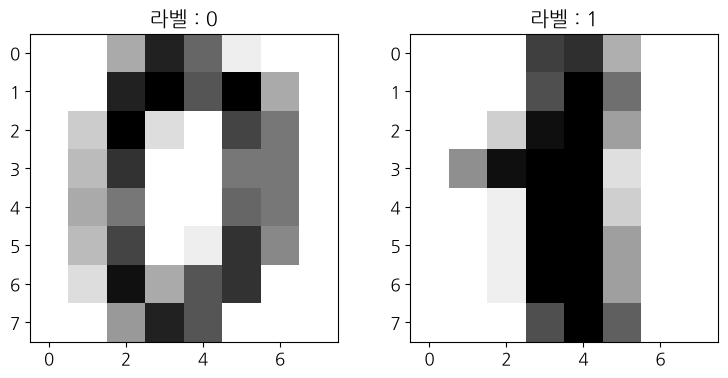

In [61]:
labels = digits.target
#데이터 셋의 라벨의 종류 0~9까지의 숫자
print(digits.target_names)
#시각화 
plt.figure(figsize=(9,4))
for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.imshow(digits.images[i],cmap=plt.cm.gray_r)
    plt.title(f'라벨 : {labels[i]}')
plt.show()

In [62]:
digits.images[0].shape, digits.images[1].shape

((8, 8), (8, 8))

## 코사인 유사도(cosine similarity)

$ \text{cosine similarity}(\mathbf{A}, \mathbf{B}) = \frac{\mathbf{A} \cdot \mathbf{B}}{\| \mathbf{A} \| \| \mathbf{B} \|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}} $

In [63]:
# 행렬 8 x 8 벡터로 연산 64

d0_vector = digits.images[0].reshape(-1)
d1_vector = digits.images[1].reshape(-1)

d0_vector.shape, d1_vector.shape

((64,), (64,))

In [64]:
# flatten()
d0_vector = digits.images[0].flatten()
d1_vector = digits.images[1].flatten()
d0_vector.shape, d1_vector.shape

((64,), (64,))

In [65]:
# 공식적용해서 유사도 구하기
cosine_sim_value = np.dot(d0_vector,d1_vector)/(np.linalg.norm(d0_vector)*np.linalg.norm(d1_vector))
cosine_sim_value

np.float64(0.5191023426414686)

# 사이킷 런에서 데이터 매개변수 형식

- : sklearn.function([vector])

In [66]:
A = np.array([d0_vector])
A.shape, A.ndim

((1, 64), 2)

In [67]:
B = np.array([d1_vector])

In [68]:
# 사이킷런에서 제공해주는 함수 (회사에서 유사도를 구할 때 적극 추천)
from sklearn.metrics.pairwise import cosine_similarity
skcosin_sim_val = cosine_similarity(A,B)
skcosin_sim_val , skcosin_sim_val.shape, skcosin_sim_val[0][0]

(array([[0.51910234]]), (1, 1), np.float64(0.5191023426414685))

##연습 문제

- 다음 코드를 실행하면 MNIST 숫자 이미지 전체 데이터를 모두 벡터로 변환하여 하나의 넘파이 행렬 x를 만든다.
- 이 행렬을 이용하여 다음 문제를 풀어라.


from sklearn.datasets import load_digits

X = load_digits().data

digits = load_digits()



In [69]:
from sklearn.datasets import load_digits
X = load_digits().data
digits = load_digits()

In [70]:
X.shape

(1797, 64)

In [71]:
X[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [72]:
#1) 내적을 이용하여 첫번째 이미지와 10번째 이미지의 유사도를 구하여라. (시각화 포함)

[[0.78087903]]
******************************


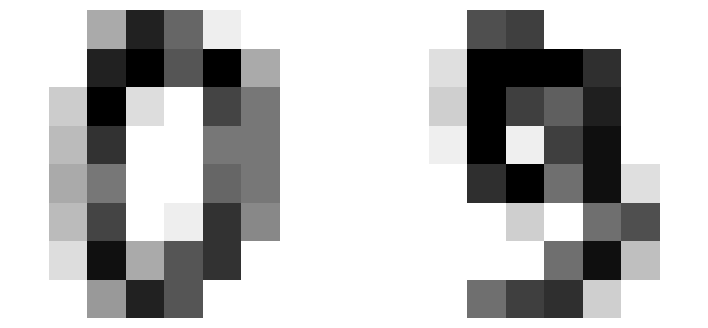

In [73]:
from sklearn.datasets import load_digits
from sklearn.metrics.pairwise import cosine_similarity

X = load_digits().data
digits = load_digits()

A = X[0].reshape(1, -1)
B = X[9].reshape(1, -1)

#A = X[0].flatten() => 2차원 배열이 아니기 때문에 cosine_similarity 함수에 넣을 수 없다.
#B = X[10].flatten()
#Reshape your data either using array.reshape(-1, 1) 
#if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

simval = cosine_similarity(A, B)
print(simval)
print('*'*30)
plt.figure(figsize=(9,4))
listv = [0,9]
for i in range(2):
    plt.subplot(1,2, i+1)
    plt.imshow(digits.images[listv[i]], cmap=plt.cm.gray_r)
    plt.axis('off')
plt.show()


In [74]:
X = load_digits().data
digits = load_digits()
def mycosine_similarity(A, B):
    return np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

In [75]:
sims = np.array([mycosine_similarity(X[0], img) for img in X])
print(f"0번째 이미지와 유사한 데이터 찾기 => {sims}")

0번째 이미지와 유사한 데이터 찾기 => [1.         0.51910234 0.61684198 ... 0.71121668 0.82580797 0.74430965]


In [76]:
most_sim_index = np.argsort(sims)[::-1][1:]
print(f"유사도가 높은 순으로 정렬(자기 자신은 제외)한 인덱스 => {most_sim_index}")
top_10 = [(index, sims[index]) for index in most_sim_index[:10]]
print(f"상위 10개 유사한 이미지의 인덱스와 유사도 => {top_10}")

유사도가 높은 순으로 정렬(자기 자신은 제외)한 인덱스 => [ 877  464 1365 ... 1213 1631 1626]
상위 10개 유사한 이미지의 인덱스와 유사도 => [(np.int64(877), np.float64(0.9807386373853507)), (np.int64(464), np.float64(0.9744736605756292)), (np.int64(1365), np.float64(0.9741884555651185)), (np.int64(1541), np.float64(0.9718313651280307)), (np.int64(1167), np.float64(0.971130132636595)), (np.int64(1029), np.float64(0.9708584122550116)), (np.int64(396), np.float64(0.9687932204179077)), (np.int64(1697), np.float64(0.966018826643372)), (np.int64(646), np.float64(0.965489736237586)), (np.int64(1342), np.float64(0.9639901017889236))]


In [77]:
aa = np.array([1,3,5,2,10,11])
#높은 순으로 정렬했을 때 인덱스 반환
aa_index = np.argsort(aa)[::-1]
aa_index

array([5, 4, 2, 1, 3, 0])

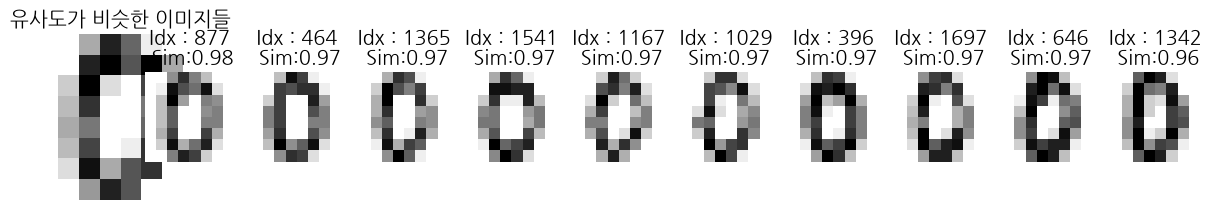

In [78]:
plt.figure(figsize=(15,3))
plt.subplot(1, 6, 1)
plt.imshow(X[0].reshape(8,8),cmap=plt.cm.gray_r)
plt.axis('off')
plt.title('유사도가 비슷한 이미지들')
for i , (index, sim) in enumerate(top_10,start=1):
    plt.subplot(1, 11, i+1)
    plt.imshow(X[index].reshape(8,8),cmap=plt.cm.gray_r)
    plt.title(f'Idx : {index}\n Sim:{sim:.2f}')
    plt.axis('off')
plt.show()

In [79]:
top_10[0] , type(top_10[0])

((np.int64(877), np.float64(0.9807386373853507)), tuple)

In [80]:
np.array(top_10).shape

(10, 2)

In [81]:
#유사도가 높은 상위 10개의 데이터 DataFrame으로 변환
df = pd.DataFrame(top_10, columns=['Index', 'Similarity']).set_index('Index')
df.head(2)

,Similarity
Index,
877,0.980739
464,0.974474


In [82]:
# Map 제너레이터 -> Index, 컬럼을 쌍으로 반환
df.itertuples()

In [83]:
list(df.itertuples())[:3]

[Pandas(Index=877, Similarity=0.9807386373853507),
 Pandas(Index=464, Similarity=0.9744736605756292),
 Pandas(Index=1365, Similarity=0.9741884555651185)]

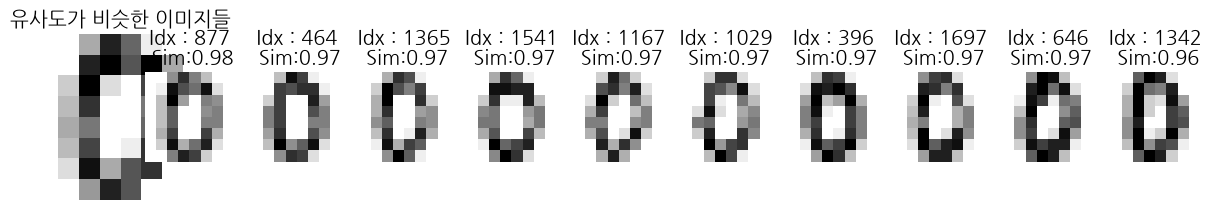

In [84]:
plt.figure(figsize=(15,3))
plt.subplot(1, 6, 1)
plt.imshow(X[0].reshape(8,8),cmap=plt.cm.gray_r)
plt.axis('off')
plt.title('유사도가 비슷한 이미지들')
for i , row in enumerate(df.itertuples(),start=1):
    plt.subplot(1, 11, i+1)
    plt.imshow(X[row.Index].reshape(8,8),cmap=plt.cm.gray_r)
    plt.title(f'Idx : {row.Index}\n Sim:{row.Similarity:.2f}')
    plt.axis('off')
plt.show()

## argmax(), argmin() *******

- : 최대값, 최소값의 인덱스를 반환해주는 함수
- 최대값이 "어디에 있는지" 반환, 최소값이 "어디에 있는지" 반환

In [85]:
#다음 행렬의 곱을 출력하시오.
#A = np.array([[1,2,3],[4,5,6]]) #3x2
#B = np.array([[1,2],[3,4],[5,6]]) # 2x3
#A 와 B를 np.arange(), reshape을 사용해서 위의 A, B의 행렬로 변경해보기

#결과)
A = np.arange(1, 7).reshape(2, -1)
B = np.arange(1, 7).reshape(3, -1)

A@B

array([[22, 28],
       [49, 64]])

In [91]:
n1 = np.arange(1,5)
n2 = np.arange(4,8)
n1, n2

(array([1, 2, 3, 4]), array([4, 5, 6, 7]))

In [94]:
# 좌우로 붙이는 함수 : row의 개수는 동일해야 한다.
np.hstack((n1,n2))

array([1, 2, 3, 4, 4, 5, 6, 7])

In [95]:
n3 = np.arange(5,10)
print(n1, n3)

[1 2 3 4] [5 6 7 8 9]


In [97]:
np.hstack((n1, n3))

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [98]:
#위아래로 붙이는 함수 : col의 개수는 동일해야 한다.
np.vstack((n1, n2))

array([[1, 2, 3, 4],
       [4, 5, 6, 7]])

In [99]:
#컬럼이 다른 n1, n3는 ?? np.vstack(()) 일경우 오류가 발생한다.
n1.shape, n3.shape

((4,), (5,))

In [101]:
#ValueError가 발생한다. col의 개수가 동일하지 않기 때문이다.
#np.vstack((n1, n3))
#ValueError: all the input array dimensions except for the concatenation axis must match exactly, 
#but along dimension 1, the array at index 0 has size 4 and the array at index 1 has size 5

In [104]:
#np.concatenate
##axis=1로 concatenate를 할 경우 열을 추가하는 동작
c = np.array([[1,2],[3,4]])
d = np.array([[5],[6]])
np.concatenate((c,d), axis=1)

array([[1, 2, 5],
       [3, 4, 6]])

In [113]:
e = np.array([[1,2],[3,4]])
f = np.array([[5,6]])
print(e.shape,f.shape)

print(f.reshape(2,1))
f_reshape = f.reshape(2,1)
##배열의 차원이 맞지 않아서 ValueError
#result = np.concatenate((e,f),axis=1)
result = np.concatenate((e,f_reshape), axis=1)
print(result)

(2, 2) (1, 2)
[[5]
 [6]]
[[1 2 5]
 [3 4 6]]


In [114]:
#다시 n1, n2
n1, n2

(array([1, 2, 3, 4]), array([4, 5, 6, 7]))

In [116]:
# 기본값 axis = 0 행
np.concatenate((n1, n2),axis=0)

array([1, 2, 3, 4, 4, 5, 6, 7])

In [117]:
n1 = np.arange(1,5)
n2 = np.arange(4,8)
n1.shape, n2.shape

((4,), (4,))

In [121]:
n1_2d = n1.reshape(1,-1)
n1_2d, n1_2d.shape

(array([[1, 2, 3, 4]]), (1, 4))

In [124]:
n1_2d = n1.reshape(1, -1).T #전치행렬(transpose)
n1_2d, n1_2d.shape

(array([[1],
        [2],
        [3],
        [4]]),
 (4, 1))

In [127]:
n1_2d = n1.reshape(1, -1).T
n2_2d = n2.reshape(1, -1).T

n1_2d, n2_2d

(array([[1],
        [2],
        [3],
        [4]]),
 array([[4],
        [5],
        [6],
        [7]]))

In [130]:
#axis = 1 열 합침 => 새로운 열(세로줄)을 추가하여 두번째 array를 붙인다.
result = np.concatenate((n1_2d,n2_2d), axis=1)
result

array([[1, 4],
       [2, 5],
       [3, 6],
       [4, 7]])

## np.array 브로드캐스팅

- np.arange(3) + 5
- np.ones((3,3)1) + np.arange(3)
- np.arange(3).reshape((3,1)) + np.arange(3)

In [179]:
print(np.arange(3) + 5)
#np.ones(3,3) + np.arange(3)
print(np.arange(3).reshape(3,1) + np.arange(3))

[5 6 7]
[[0 1 2]
 [1 2 3]
 [2 3 4]]


In [140]:
#위의 그림을 보고 코드를 완성해보기
np.arange(3) + np.array([5]), np.arange(3) + 5

(array([5, 6, 7]), array([5, 6, 7]))

In [141]:
np.ones((3,3)) + np.arange(3), np.ones((3,3)) + np.array([[0,1,2]])

(array([[1., 2., 3.],
        [1., 2., 3.],
        [1., 2., 3.]]),
 array([[1., 2., 3.],
        [1., 2., 3.],
        [1., 2., 3.]]))

In [142]:
np.ones((3,3)).shape, np.arange(3).shape

((3, 3), (3,))

In [144]:
np.ones((3,3)).shape, np.array([[0,1,2]]).shape

((3, 3), (1, 3))

In [145]:
# 두 차원의 크기가 같으면 된다.
# 한쪽이 1이면 그 차원을 확장해서 맞출 수 있음.
# (3,3) 와 (1,3) => 마지막 차원 : 3 vs 3 => 같음, 그앞 차원 : 3 vs 1 => 1은 확장 가능

In [149]:
np.arange(3).reshape((3,1)).shape, np.arange(3).shape

((3, 1), (3,))

In [150]:
np.arange(3).reshape((3,1)) + np.arange(3)

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

In [152]:
b1 = np.ones((3,3))
b1

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [153]:
b2 = np.arange(6).reshape(2, 3)
b2

array([[0, 1, 2],
       [3, 4, 5]])

In [155]:
b1.shape, b2.shape

((3, 3), (2, 3))

In [164]:
#b1 + b2

In [173]:
A = np.array([[1,3],[2,4]]).T
B = np.array([[1],[2]])
print(A)
print(B)

[[1 2]
 [3 4]]
[[1]
 [2]]


In [184]:
B_broadcast = np.concatenate((B,B),axis=1)
print(B_broadcast)
AB_broadcast = A + B
print(AB_broadcast)

[[1 1]
 [2 2]]
[[2 3]
 [5 6]]


In [190]:
arr1 = np.array([[4,5,6]]).T
print(arr1)
arr2 = np.array([[1,2,3]])
print(arr2)

result = arr1 + arr2
print(result)

[[4]
 [5]
 [6]]
[[1 2 3]]
[[5 6 7]
 [6 7 8]
 [7 8 9]]


## 행렬 생성

- 영벡터(zero-vector) : 모든 원소가 0인 N차원 벡터 : 0은 거짓이나, <span style="color:red">가중치 초기화 목적</span>으로 사용한다.
- 일벡터(ones-vector) : 모든 원소가 1인 N차원 벡터
- 정방행렬 (square matrix) : 행의 개수와 열의 개수가 같은 행렬
- 단위행렬은 대각원소가 1이고, 나머지는 모두 0인 n차 정방행렬
- 대각행렬 :  비 대각 성분이 0 인 행렬
- 항등행렬 : 대각행렬 중에서도 모든 대각성분의 값이 1인 대각행렬
- 전치행렬 : 행렬의 행과 열을 바꾸는 연산

In [194]:
N = 5
zero_vector = np.zeros(N)
zero_vector ,  zero_vector.ndim, zero_vector.shape

(array([0., 0., 0., 0., 0.]), 1, (5,))

In [195]:
# 5x4 행렬 - 영벡터
np.zeros((5,5))

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [196]:
# 1로 채우는 벡처 -ones(N)
ones_vector = np.ones(N)
ones_vector

array([1., 1., 1., 1., 1.])

In [198]:
square_matrix = np.arange(1,10).reshape(3,3)
print("3x3정방행렬")
print(square_matrix)

3x3정방행렬
[[1 2 3]
 [4 5 6]
 [7 8 9]]


### 단위행렬: 좌측 상단으로부터 우측 하단까지 대각선 성분들이 모두 1이고, 나머지 성분들은 0

- 단위행렬은 대각원소가 1이고, 나머지는 모두 0인 n차 정방행렬을 말하며, numpy의 eye() 함수를 사용

In [200]:
np.eye(2), np.eye(3)

(array([[1., 0.],
        [0., 1.]]),
 array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]))

In [202]:
list(range(1,6)) , [x for x in range(1,6)]

([1, 2, 3, 4, 5], [1, 2, 3, 4, 5])

In [205]:
#정방 행렬에서 주 대각 성분을 제외한 나머지 요소의 값이 0인 행렬을 대각 행렬(diagonal matrix)라고 한다.
# 대각행렬
# - 비 대각 성분이 0이기만 하면 된다.
#전치행렬이 자기 자신과 같다.
np.diag(list(range(1,6)))

array([[1, 0, 0, 0, 0],
       [0, 2, 0, 0, 0],
       [0, 0, 3, 0, 0],
       [0, 0, 0, 4, 0],
       [0, 0, 0, 0, 5]])

In [209]:
# k값 속성으로 대각의 방향을 설정
mt = np.diag(list(range(1,6)))
np.diag(mt, k=0), np.diag(mt, k=1), np.diag(mt, k=-1), np.diag(mt,k=2), np.diag(mt, k=4)

(array([1, 2, 3, 4, 5]),
 array([0, 0, 0, 0]),
 array([0, 0, 0, 0]),
 array([0, 0, 0]),
 array([0]))

In [211]:
# 항등행렬 => 단위 행렬(영어: unit matrix) 같은 말이다.
# - 대각행렬 중에서도 모든 대각성분의 값이 1인 대각행렬을 말한다.
np.eye(3), np.identity(3)

(array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]))

In [213]:
# 전치행렬
# 행렬의 행과 열을 바꾸는 연산
x = np.array([[11,12,13], [21,22,23]])
x, x.T

(array([[11, 12, 13],
        [21, 22, 23]]),
 array([[11, 21],
        [12, 22],
        [13, 23]]))

In [214]:
# 2x5를 모두 지정한 숫자로 채우는 함수? 
#행 (row) : 가로줄
#열 (column) : 세로

np.full((2,5),1)

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]])